<a href="https://colab.research.google.com/github/AndreaBravo-DA/Proyecto_An-lisis-de-empresa-de-telecomunicaciones-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans

plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users

users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage

usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()

usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Cantidad de valores nulos:',users.isna().sum())
print('Proporción de valores nulos:', users.isna().mean())

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('Cantidad de valores nulos:', usage.isna().sum())
print('Proporción de valores nulos:', usage.isna().mean())


Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


## ✍️ **Comentario**:


Para el dataset  `users ` se tienen valores nulos en dos columnas. Para la columna  `City ` se tienen 469 nulos del total de 4000 datos. Lo que representa un 11.72%, por lo que se recomienda realizar una investigación para imputar, puesto que es importante la columna para realizar un sondeo por segmentos demográficos.

La segunda columna  `churn_date ` tiene un total de 3534 valores nulos, lo que representa un 88.35% de datos faltantes, se sugiere ignorar los datos nulos puesto que se tendría un gran sesgo al querer completarlos. Es importante mencionar que las filas en las cuales la fecha aparece con registro, es debido a que el usuario dejó de utilizar la línea, se puede interpretar como "bajas de usuarios". Mientras que las lineas con nulos, son líneas que continuan en servicio. No se deberán imputar los datos puesto que se tendría un error al querer analizar las líneas activas y las líneas dadas de baja.

En el dataset  `usage ` se tiene un total de 40000 datos, dentro de este existen 3 columnas con datos nulos. Para la columna  `date ` se tiene un faltante de 50 datos, se recomienda eliminar estas filas ya que representan solo el 0.12% del total. En la siguiente columna  `duration ` se tiene un faltante del 55.19% (22076 datos) por lo que se sugiere dejarlo como nulos hasta que no se realice un filtrado de la información (si la fila corresponde a llamada o mensaje), en caso de ser llamada y tener valor nulo, se sugiere imputar. Al ser mensaje, se sugiere ignorar.

Para  `length ` se tiene un faltante total de 17896 datos, lo que representa un 44.74%. Se sugiere dejar los datos como nulos hasta que se realice un filtrado (si la fila corresponde a llamada o mensaje). En caso de ser mensaje y ser nulo, el valor nulo se deberá imputar. Al ser llamada, se sugiere ignorar.



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- En la columna `user_id`, la media es mayor que la desviación estándar por lo que se puede decir que los datos son relativamente estables y consistentes. Los valores extremos no presentan una gran diferencia. Los percentiles son relativamente homogéneos.
  
- En la columna `age`, la media es menor que la desviación estándar por lo que se tiene una alta variabilidad en los datos. El valor mínimo es un dato que se capturó erróneamente, conocido como "valor centinela", por lo que se tienen sesgos hacia la izquierda en la información.

In [ ]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- En las columnas `id` y `user_id`, la media es mayor que la desviación estándar por lo que se puede decir que los datos son relativamente estables y consistentes, puesto que estas columnas son indicadores. Los valores extremos no presentan una gran diferencia. Los percentiles son relativamente homogéneos.
  
- En la columna `duration`, la media es menor que la desviación estándar, por lo que se tiene una alta variabilidad en los datos. El valor mínimo es 0.00, por lo que las filas que contienen dicho valor corresponden a un mensaje. Se deberá descartar dichas filas con duración de 0.00 para conocer el verdadero valor mínimo, mientras que el valor máximo es 120.00 minutos. Los percentiles son relativamente homogéneos.

- En la columna `length`, la media es menor que la desviación estándar, lo que indica que se tiene una variabilidad alta en los datos. La longitud mínima es de 0.00, por lo que se interpreta que dichas filas con este valor corresponden a un dato que se capturó erróneamente, conocido como "valor centinela". El valor máximo es de 1490 caracteres. Los percentiles son relativamente homogéneos.

In [ ]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene un total de 3531 datos, de los cuales en 808 registros se tiene a Bogotá como ciudad. Existen dentro del dataset el registro de 7 ciudades distintas.
  
- La columna `plan` cuenta con 4000 datos, de los cuales se clasifican en 2 únicos. El tipo de plan que más se presenta es el básico con 2595 registros.

In [ ]:
# explorar columna categórica de usage

usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 40000 registros de los cuales se clasifican en 2 tipos. De los cuales la mayoría son del tipo texto, puesto que se tienen 22092 filas con esta categoría. El tipo de dato en que se almacena es texto.


---
✍️ **Comentario**:

En el dataset `users` dentro de la columna `age` se tiene el valor -999 como dato centinela, se sugiere imputar dichos valores con la mediana.

En el dataset `usage` se tiene el valor 0.00 de la columna `length` como sentienel puesto que no se puede tener un registro de  mensaje con el dato de 0.00 caracteres. Se sugiere convertir los registros con 0.00 a NaN ya que se desconoce el valor.


Para la columna `city` se tienen valores con '?' por lo que se sugiere convertir los registros de las filas a NaN.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors= 'coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'],errors= 'coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users

users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se tiene registro de 4 años. Se observa que no se tiene registro del año 2025. Se tiene un total similar de registros entre los años del 2022 al 2024 (~1300 cada uno). Para 2026 se tiene solo 40 registros, por lo que se podría enteder que son datos de inicio de año. Se recomienda descartar los datos de 2026 puesto que son incompletos.

In [ ]:
# Revisar los años presentes en `date` de usage

usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date`, solo se tienen registros de 2024. En total se tienen 39950 registros. Se deberá estandarizar el año puesto que se marca con decimales.  

##Nota: Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age


#Función para reemplazar sentinelas númericas por un valor ausente (NA)

def reemplazar (df,sentinelas,columnas):
   for col in columnas:
    df[col] = df[col].replace(sentinelas, pd.NA)

    return df

#---------------------------------------------------------------

#Función para rellenar los valores ausentes (NA) con la mediana

def rellenar_ausentes (df,columna_fill):
    for col in columna_fill:
        df[col]= pd.to_numeric(df[col],errors='coerce')
        df[col].fillna(df[col].median(), inplace=True)

        return df

#--------------------------------------------------------------

#Fijar los valores a corregir y columnas

def limpiar (df):
    valor_erroneo = [-999] #Escribir los valores erroneos o valor sentinela
    columna = ['age'] #Definir la columna a la que se aplicara la corrección

    df= reemplazar(df,valor_erroneo,columna)

    df= rellenar_ausentes(df,columna)

    return df

users = limpiar(users)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

#Función para reemplazar sentinelas númericas por un valor ausente (NA)

def reemplazar (df,sentinelas,columnas):
   for col in columnas:
    df[col] = df[col].replace(sentinelas, pd.NA)

    return df

#--------------------------------------------------------------

#Fijar los valores a corregir y columnas

def limpiar (df):
    dato_erroneo = ['?'] #Escribir los valores erroneos o valor sentinela
    columna = ['city'] #Definir la columna a la que se aplicara la corrección

    df= reemplazar(df,dato_erroneo,columna)

    return df

users = limpiar(users)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date

#Función para reemplazar sentinelas númericas por un valor ausente (NA)

def reemplazar (df,sentinelas,columnas):
   for col in columnas:
    mascara= df[col].dt.year == int(sentinelas[0])
    df.loc[mascara,col] = pd.NaT

    return df

#--------------------------------------------------------------

#Fijar los valores a corregir y columnas

def limpiar (df):
    dato_erroneo = ['2026'] #Escribir los valores erroneos o valor sentinela
    columna = ['reg_date'] #Definir la columna a la que se aplicara la corrección

    df= reemplazar(df,dato_erroneo,columna)

    return df

users = limpiar(users)

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length

usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

En los nulos de `duration` y `length` se observa que son un tipo MAR puesto que su ausencia depende de otra variable observable. Se dejaran como nulos puesto que estos significan ausencias debido a que el tipo es correcto, es decir, el mensaje sale nulo puesto que no tiene duración, mientras que la llamada presenta nulos porque no tiene una longitud de caracteres.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id")["is_text","is_call","duration"].sum().reset_index()

# observar resultado

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas

usage_agg= usage_agg.rename(columns= {
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(
    users,
    usage_agg,
    on = 'user_id',
    how = 'left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
#Calcular la media por tipo de plan

columna= ['cant_mensajes','cant_llamadas']

user_profile.groupby('plan')[columna].agg('mean')

,cant_mensajes,cant_llamadas
plan,,
Basico,5.527756,4.456438
Premium,5.518149,4.518149


In [ ]:
#Calcular la mediana por tipo de plan

columna= ['cant_mensajes','cant_llamadas']

user_profile.groupby('plan')[columna].agg('median')


,cant_mensajes,cant_llamadas
plan,,
Basico,5.0,4.0
Premium,5.0,4.0


In [ ]:

#Calcular la moda por tipo de plan

columna= ['cant_mensajes','cant_llamadas']

user_profile.groupby('plan')[columna].agg(pd.Series.mode)


,cant_mensajes,cant_llamadas
plan,,
Basico,6.0,4.0
Premium,5.0,"[3.0, 4.0]"


In [ ]:

# Calcular media de los minutos de llamada por tipo de plan

columna= ['cant_minutos_llamada']

user_profile.groupby('plan')[columna].agg('mean')

,cant_minutos_llamada
plan,
Basico,22.905436
Premium,24.077011


In [ ]:
# Calcular mediana de los minutos de llamada por tipo de plan

columna= ['cant_minutos_llamada']

user_profile.groupby('plan')[columna].agg('median')

,cant_minutos_llamada
plan,
Basico,19.535
Premium,20.640


In [ ]:
# Distribución porcentual del tipo de plan

plans.value_counts()

plan_name  messages_included  gb_per_month  minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute
Basico     100                5             100               12               1.2         0.08             0.10              1
Premium    500                20            600               25               1.0         0.05             0.07              1
dtype: int64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

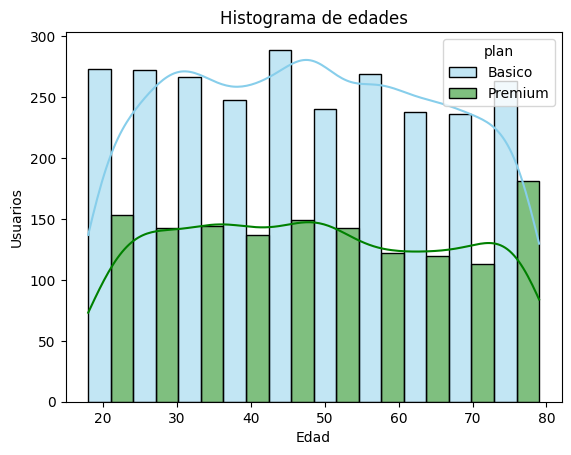

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile,x='age',bins=10,kde=True, hue='plan', palette= ['skyblue','green'],multiple='dodge')
plt.title("Histograma de edades")
plt.xlabel("Edad")
plt.ylabel("Usuarios")

plt.show()

💡Insights:

- El histrograma muetsra que se tiene una mayor cantidad de usuarios en planes basicos. La mayoria de edad son entre los 40-50 años, posteriormente los usuarios se concentran entre la edad de los 20 a los 30 años.
- Para los planes premium tiene un mayor auge entre usuarios de casi los 80 años.
- La distribución del campo age es simétrica porque:
  · La media (48.13) y la mediana (48.00) son casi iguales
  · No hay una cola larga hacia ningún lado
  · Los datos están balanceados alrededor del centro

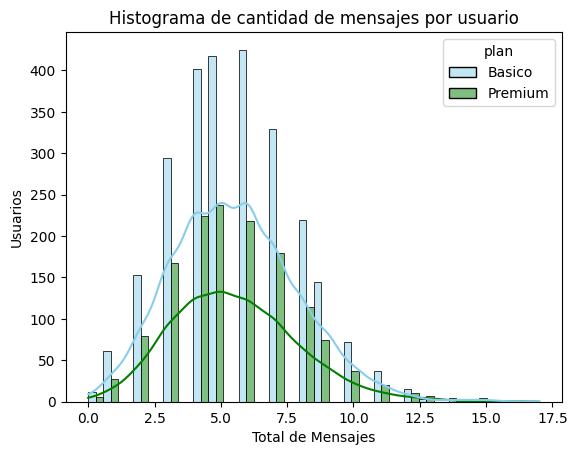

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile,x='cant_mensajes',bins=30,kde=True,hue='plan',palette=['skyblue','green'], multiple='dodge')
plt.title("Histograma de cantidad de mensajes por usuario")
plt.xlabel("Total de Mensajes")
plt.ylabel("Usuarios")

plt.show()

💡Insights:

- Para el plan basico se tiene un sesgo hacia la derecha, la media (5.527) es mayor que la mediana (5).

- En el plan premium se tiene un sesgo hacia la derecha,  la media (5.518) es mayor que la mediana (5).

- Para el plan basico, la mayoria de los usuarios tiene un uso de 6 mensajes.

- Para el plan premium la mayoria esta en los 5 mensajes.

- El plan basico tiene un comportamiento variado entre la cantidad de mensajes que se envian entre los usuarios, es de forma platicúrtica.

- El plan preminum se tiene una distribucion más concentrada por lo que se tiene un pico pronunciado. Es de tipo leptocurtica con una dispersion pequeña de los datos.



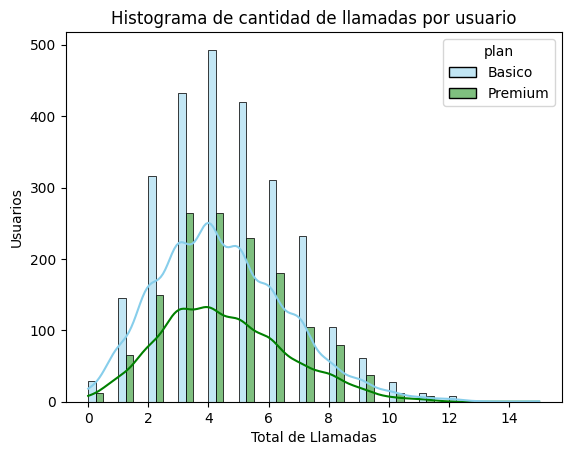

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile,x='cant_llamadas',bins=30,kde=True,hue='plan',palette=['skyblue','green'], multiple='dodge')
plt.title("Histograma de cantidad de llamadas por usuario")
plt.xlabel("Total de Llamadas")
plt.ylabel("Usuarios")

plt.show()

💡Insights:

- Para el plan basico se tiene un sesgo hacia la derecha, la media (4.456) es mayor que la mediana (4).

- En el plan premium se tiene un sesgo hacia la derecha,  la media (4.518) es mayor que la mediana (4).

- Para el plan basico, la mayoria de los usuarios tiene un uso de 4 llamadas.

- Para el plan premium, la mayoria de los usuarios esta entre 3 y 4 llamadas. Por lo que es una distribución bimodal.

- El plan basico tiene un comportamiento centrado entre la cantidad de llamadas entre los usuarios, tiene un pico alargado y pronunciado, es de forma leptocurtica.

- El plan premium tiene un comportamiento variado entre la cantidad de llamadas que realizan los usuarios, es de forma platicúrtica.

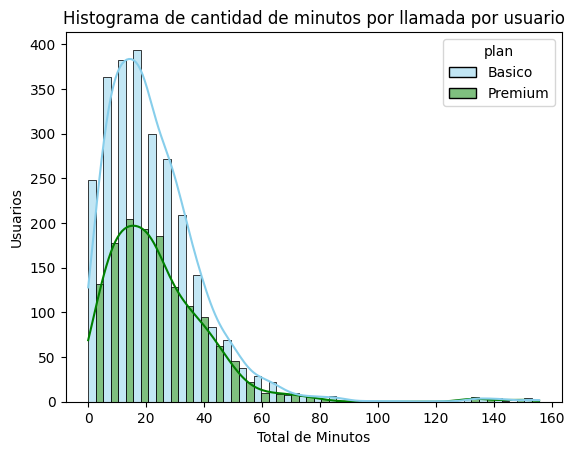

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile,x='cant_minutos_llamada',bins=30,kde=True,hue='plan',palette=['skyblue','green'], multiple='dodge')
plt.title("Histograma de cantidad de minutos por llamada por usuario")
plt.xlabel("Total de Minutos")
plt.ylabel("Usuarios")

plt.show()

💡Insights:

- Para ambos planes se tiene un sesgo hacia la derecha puesto que la media es mayor que la mediana. Basico: media: 22.905 y mediana: 19.535.
Premium: media: 24.077 y mediana: 20.640.

- En el plan basico se tiene un comportamiento centrado entre la cantidad de minutos que se tienen en una llamada, por lo que se tiene un pico alargado, es de forma leptocurtica.

- Para el plan premium se observa un pico más plano, por lo que se tiene una forma platicúrtica.

- Para el plan basico la mayoria de los usuarios realizaron llamadas cerca de los 15-20 minutos de duración.

- La mayoría de los usuarios del plan Premium realizaron llamadas de aproximadamente 20 minutos de duración.

- El plan que tiene más minutos de llamadas registrados por usuarios es el basico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

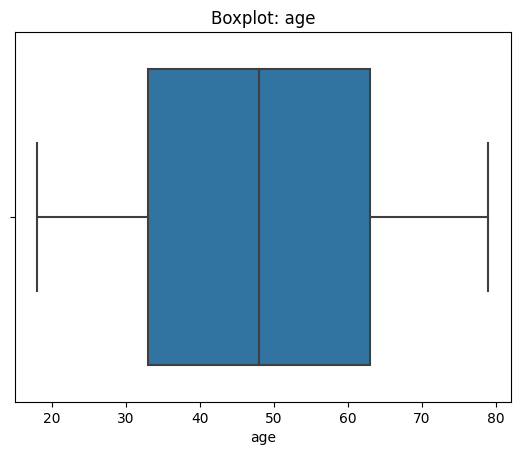

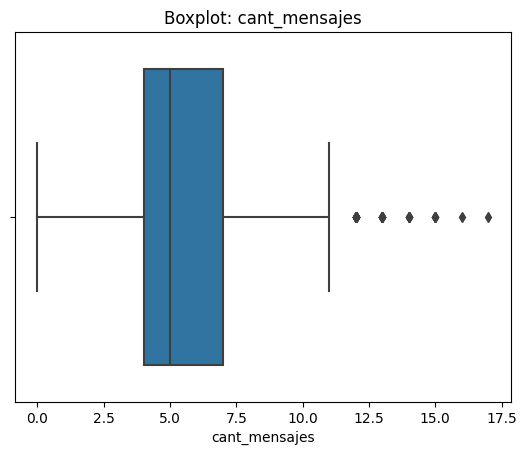

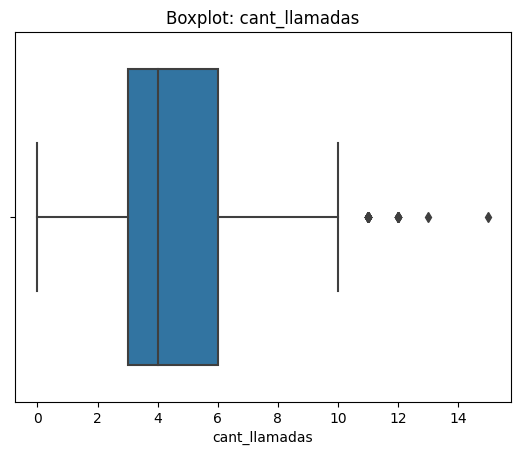

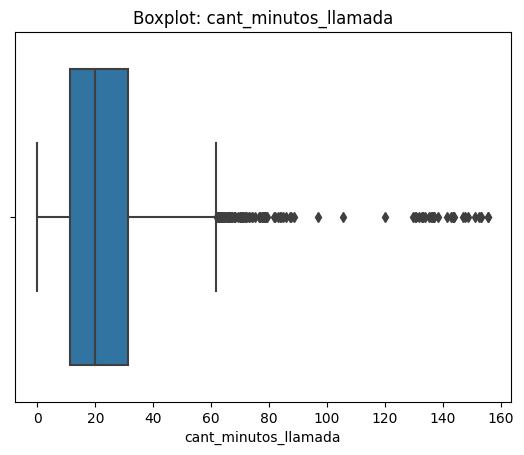

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_numericas:

    sns.boxplot(data=user_profile,x=col),

    plt.title(f'Boxplot: {col}')


    plt.show()




💡Insights:
- Age: no se tiene presentacia de outliers.
- cant_mensajes: presenta 6 outliers.
- cant_llamadas: presenta 4 outliers.
- cant_minutos_llamada: tiene presencia de diversos outliers.

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    q1= user_profile[col].quantile(0.25)
    q3= user_profile[col].quantile(0.75)
    iqr= q3-q1
    limite_superior= q3+1.5*iqr
    print(f'{col}: Q1={q1}, Q3={q3}, IQR={iqr}, Límite superior={limite_superior}')


cant_mensajes: Q1=4.0, Q3=7.0, IQR=3.0, Límite superior=11.5
cant_llamadas: Q1=3.0, Q3=6.0, IQR=3.0, Límite superior=10.5
cant_minutos_llamada: Q1=11.12, Q3=31.415, IQR=20.295, Límite superior=61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes: Los valores se consideran posibles pero extremos, se debe capear los datos, ademas de que aportan información clave para las metricas. El limite superior es de 11.5, mientras que el valor máximo es de 17.
  
- cant_llamadas: Los valores se consideran reales y representan datos reales, ademas de que aportan información clave para las metricas. Se debe capear los datos, el limite superior es de 10.5, mientras que el valor máximo es 15.

- cant_minutos_llamada: Los valores se consideran extremos, por lo que lo mejor es capar la información. Ademas es una columna con información variable. Limite superior: 61.8575, mientras que el valor maximo es 155.69.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


condiciones = [
    (user_profile['cant_mensajes'] <5) & (user_profile['cant_llamadas'] <5),
    (user_profile['cant_mensajes'] <10) & (user_profile['cant_llamadas'] <10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile["grupo_uso"] = np.select(condiciones, valores, default='Alto uso')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

condiciones = [
    (user_profile['age'] <30),
    (user_profile['age'] <60)
]

valores = ['Joven', 'Adulto']

user_profile["grupo_edad"] = np.select(condiciones, valores, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

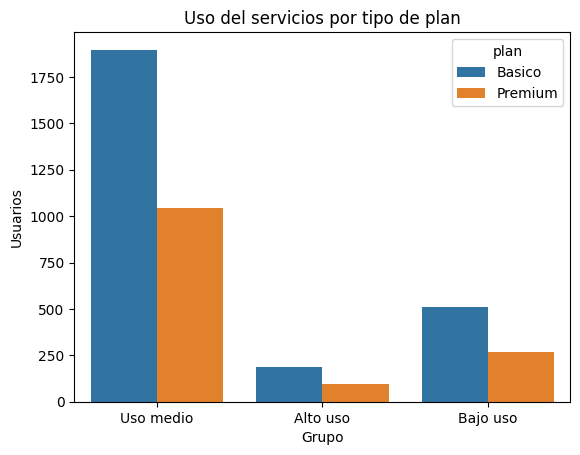

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile,x='grupo_uso', hue='plan')
plt.title('Uso del servicios por tipo de plan')

plt.xlabel('Grupo')
plt.ylabel('Usuarios')


plt.show()

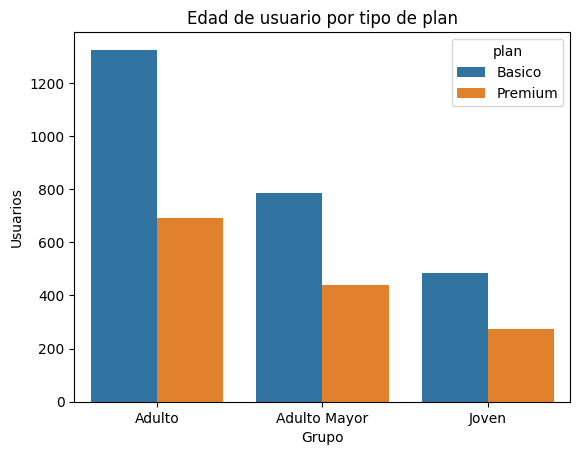

In [ ]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile,x='grupo_edad', hue='plan')
plt.title('Edad de usuario por tipo de plan')
plt.xlabel('Grupo')
plt.ylabel('Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Para el dataset  `users ` se tienen valores nulos en dos columnas. Para la columna  `City ` se tienen 469 nulos del total de 4000 datos. Lo que representa un 11.72%, por lo que se recomienda realizar una investigación para imputar, puesto que es importante la columna para realizar un sondeo por segmentos demográficos.

- La segunda columna  `churn_date ` tiene un total de 3534 valores nulos, lo que representa un 88.35% de datos faltantes, se sugiere ignorar los datos nulos puesto que se tendría un gran sesgo al querer completarlos.

Es importante mencionar que las filas en las cuales la fecha aparece con registro, es debido a que el usuario dejó de utilizar la línea, se puede interpretar como "bajas de usuarios".

Mientras que las lineas con nulos, son líneas que continuan en servicio. No se deberán imputar los datos puesto que se tendría un error al querer analizar las líneas activas y las líneas dadas de baja.

- En el dataset  `usage ` se tiene un total de 40000 datos, dentro de este existen 3 columnas con datos nulos. Para la columna  `date ` se tiene un faltante de 50 datos, se recomienda eliminar estas filas ya que representan solo el 0.12% del total. En la siguiente columna  `duration ` se tiene un faltante del 55.19% (22076 datos) por lo que se sugiere dejarlo como nulos hasta que no se realice un filtrado de la información (si la fila corresponde a llamada o mensaje), en caso de ser llamada y tener valor nulo, se sugiere imputar. Al ser mensaje, se sugiere ignorar.

- Para  `length ` se tiene un faltante total de 17896 datos, lo que representa un 44.74%. Se sugiere dejar los datos como nulos hasta que se realice un filtrado (si la fila corresponde a llamada o mensaje). En caso de ser mensaje y ser nulo, el valor nulo se deberá imputar. Al ser llamada, se sugiere ignorar.



🔍 **Segmentos por Edad**

- El grupo de jovenes es una oportunidad para la compañia, puesto que son los usuarios quienes utilizan menos el plan básico y premium. La mayoria de los usuarios son adultos, posteriormente quienes lo usan son los adultos mayores.
  
- En los tres grupos de usuarios por edad prefieren utilizar el plan basico.


📊 **Segmentos por Nivel de Uso**

- El plan basico es el preferido entre usuarios, puesto que tanto en el uso medio, bajo y alto del servicios es el plan con mas usuarios registrados.
  
- Para el plan premium se tiene un uso medio con más frecuencia, mientras que los usuarios con un alto uso son la minoria en este tipo de plan. Por lo que se deben realizar acciones como beneficios exclusivos para plan premium.


➡️ Esto sugiere que la mayoria de los usuarios prefieren utilizar el plan basico. Por lo que se deben realizar acciones para que los usuarios prefieran utilizar el plan premium.


💡 **Recomendaciones**
- Se recomienda revisar el costo del plan premium puesto que pocos usuarios tienen ese plan activado.
- Se sugiere tener en cuenta el total de uso que tiene cada plan para modificarlo y sea más remunerable para la compañia y usuarios.
- Se sugiere realizar alguna campaña para tener más uso del plan premium entre los jovenes. Para este segmento de usuarios al momento de contratar el plan se podría dar beneficios para el usuario.
Algunos podrian ser: el uso de redes sociales ilimitado, algun convenio con una app de reproducción de música, ciertos GB de internet para juegos y navegar o tener dinamicas de recompensa por el uso del paquete (obsequiar accesorios, juntar puntos para intercambio de regalos, descuentos y ofertas especiales).
- Para los adultos mayores que tienen menos uso del plan premium se puede hacer más atractivo dando beneficios en intercambio de puntos en cosas de interes como equipos o en compra de despensa.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/AndreaBravo-DA/Proyecto_An-lisis-de-empresa-de-telecomunicaciones-ConnectaTel